### Importing packages and tables

In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import glob
import seaborn as sns

In [2]:
GABPA = 'MSLVDLGKKLLEAARAGQDDEVRILMANGAPFTTDWLGTSPLHLAAQYGHYSTTEVLLRAGVSRDARTKVDRTPLHMAASEGHASIVEVLLKHGADVNAKDMLKMTALHWATEHNHQEVVELLIKYGADVHTQSKFCKTAFDISIDNGNEDLAEILQIAMQNQINTNPESPDTVTIHAATPQFIIGPGGVVNLTDETGVSAVQFGNSSTSVLATLAALAEASAPLSNSSETPVATEEVVTAESVDGAIQQVVSSGGQQVITIVTDGIQLGNLHSIPTSGIGQPIIVTMPDGQQVLTVPATDIAEETVISEEPPAKRQCIEIIENRVESAEIEVRSLLPGVLCRSHPK'

In [3]:
table_mt = pd.read_csv('/global/scratch/users/sergiomar10/table_mt.csv')

In [4]:
table_mt = pd.read_csv('/global/scratch/users/sergiomar10/B1_analysis_share_sergio.csv')
table_mt = table_mt[table_mt['position'] != 'WT']
table_mt['position'] = table_mt['position'].astype('int')

In [5]:
table_mt.sort_values(by='position')

,seqid,Ref,position,mutation,average pTM,average ipTM,average pDockq,log_likelihood (AF2),log_likelihood_target (AF2),log_likelihood (CRYSTAL),...,pathogenicity score,pathogenicity class,ESM-C score,AF2 PTM rank,AF2 iPTM rank,AF2 pDockq rank,SE w/ AF2 rank,SE w/ crystal rank,ESM-C rank,nanobit score compared to WT
7,M1A,M,1,A,0.871628,0.895108,0.33736,-1.301548,-1.052237,NaN,...,NaN,NaN,-6.879572,652,1044,556,1318,NaN,1322,NaN
2678,M1P,M,1,P,0.871844,0.895542,0.33768,-1.306395,-1.060485,NaN,...,NaN,NaN,-7.339384,371,650,471,1546,NaN,1436,NaN
2069,M1V,M,1,V,0.871357,0.895115,0.33584,-1.295672,-1.040397,NaN,...,NaN,NaN,-5.885572,1152,1034,1079,967,NaN,1042,NaN
1370,M1F,M,1,F,0.871097,0.894412,0.33388,-1.306218,-1.061486,NaN,...,NaN,NaN,-6.749971,1534,1629,1790,1538,NaN,1292,NaN
2598,M1D,M,1,D,0.871518,0.895175,0.33736,-1.298810,-1.045954,NaN,...,NaN,NaN,-12.152748,851,966,555,1166,NaN,2712,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
842,T166R,T,166,R,0.871724,0.894927,0.33152,-1.282132,-1.013475,NaN,...,0.3262,likely_benign,-3.632400,512,1227,2313,173,NaN,517,NaN
2334,T166Q,T,166,Q,0.871712,0.895261,0.33652,-1.277669,-1.007642,NaN,...,0.3361,likely_benign,-2.906552,530,888,822,57,NaN,392,NaN
1953,T166G,T,166,G,0.872349,0.896137,0.33552,-1.296902,-1.041816,NaN,...,0.3272,likely_benign,-1.922957,100,323,1189,1037,NaN,267,NaN
323,T166C,T,166,C,0.870662,0.892949,0.32412,-1.291002,-1.031980,NaN,...,0.4515,ambiguous,-4.413748,1901,2164,2831,663,NaN,692,NaN


In [6]:
full_sequences = []

for idx, row in table_mt.iterrows():
    # make a fresh list of chars from your WT GABPA sequence
    wt_sequence = list(GABPA)
    pos = int(row['position']) - 1  # zero‑based index

    # sanity check
    if wt_sequence[pos] != row['Ref']:
        print(f"Position {pos+1} mismatch: expected {row['Ref']}, found {wt_sequence[pos]}")
        full_sequences.append(None)   # or skip, or append the WT, up to you
        continue

    # apply the mutation and re‑join
    wt_sequence[pos] = row['mutation']
    full_sequences.append(''.join(wt_sequence))

# assign back to the DataFrame
table_mt['full_sequence'] = full_sequences
table_mt.to_csv('/global/scratch/users/sergiomar10/table_mt.csv',index = False)

In [7]:
import os
import math

In [8]:
aa_prop = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/data/Amino_Acid_Properties.csv')

In [9]:
aa_prop['SideChain_Volume'] = [67, 148, 96, 91, 86, 122, 114, 48, 118, 124, 124, 135, 124, 135, 90, 73, 93, 163, 141, 105]

### Generating plots

In [101]:
# 1. mappings for clean titles and arrow direction
title_map = {
    'position':                          'Position',
    'average pTM':                       'pTM',
    'average ipTM':                      'iPTM',
    'average pDockq':                    'pDockQ',
    'log_likelihood (AF2)':              'Log‑likelihood AF2',
    ' log_likelihood_target (AF2)':      'Log‑likelihood AF2 target',
    'log_likelihood (CRYSTAL)':          'Log‑likelihood CRYSTAL',
    ' log_likelihood_target (CRYSTAL)':  'Log‑likelihood CRYSTAL target',
    'pathogenicity score':               'Pathogenicity',
    'ESM-C score':                       'ESM‑C score',
    'nanobit score compared to WT':      'Nanobit Δ',
    'delta_Hydrophobicity_KyteDoolittle':'Hydrophobicity Δ',
    'delta_Isoelectric_Point':           'pI Δ',
    'delta_SideChain_Volume':            'Volume Δ',
    'delta_Polarity_Grantham':           'Polarity Δ',
    'delta_Charge':                      'Charge Δ',
}
better_high = {m: True for m in title_map}  # True = higher is better

# 2. get up to first 5 t‑SNE files
tsne_files = glob.glob('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/umap*.csv')

for tsne_file in tsne_files:
    if 'cosine' in tsne_file:
        continue
    basename = os.path.basename(tsne_file)
    results_tsne = pd.read_csv(tsne_file)
    results_tsne.columns = ['full_sequence','TSNE1','TSNE2']

    merged_df = pd.merge(results_tsne, table_mt, on='full_sequence', how='inner')

    # compute Δ‑properties as before...
    prop_cols = [
        'Hydrophobicity_KyteDoolittle',
        'Isoelectric_Point',
        'SideChain_Volume',
        'Polarity_Grantham'
    ]
    prop_maps = {col: aa_prop.set_index('AA')[col].to_dict() for col in prop_cols}
    for col in prop_cols:
        merged_df[f'{col}_WT']    = merged_df['Ref'].map(prop_maps[col])
        merged_df[f'{col}_MT']    = merged_df['mutation'].map(prop_maps[col])
        merged_df[f'delta_{col}'] = merged_df[f'{col}_MT'] - merged_df[f'{col}_WT']
    charge_map = {'negative':-1,'neutral':0,'positive':1}
    aa_charge = aa_prop.set_index('AA')['Charge_at_pH7'].map(charge_map).to_dict()
    merged_df['Charge_WT']    = merged_df['Ref'].map(aa_charge)
    merged_df['Charge_MT']    = merged_df['mutation'].map(aa_charge)
    merged_df['delta_Charge'] = merged_df['Charge_MT'] - merged_df['Charge_WT']

    # 3. metrics and grid
    metrics = list(title_map.keys())
    n, cols = len(metrics), 3
    rows = math.ceil(n/cols)

    # 4. setup figure
    sns.set_style('white')
    fig, axes = plt.subplots(rows, cols, figsize=(cols*6, rows*6), sharex=True, sharey=True)
    fig.suptitle(basename, fontsize=16, y=0.98)
    basename = basename.replace('.csv','')

    label_offset = 30
    top_slots = [(-label_offset, label_offset),
                 (0, label_offset),
                 (label_offset, label_offset)]
    bot_slots = [(-label_offset, -label_offset),
                 (0, -label_offset),
                 (label_offset, -label_offset)]

    # 5. plot each metric
    for ax, metric in zip(axes.flatten(), metrics):
        clean_title = title_map[metric]
        arrow = '↑' if better_high[metric] else '↓'
        sns.scatterplot(
            merged_df, x='TSNE1', y='TSNE2',
            hue=metric, palette='inferno_r', alpha=0.6,
            ax=ax, legend=False
        )
        ax.set_title(f"{clean_title} {arrow}", fontsize=12)
        ax.set_xlabel('UMAP 1', fontsize=10)
        ax.set_ylabel('UMAP 2', fontsize=10)

        # colorbar
        norm = plt.Normalize(merged_df[metric].min(), merged_df[metric].max())
        sm   = plt.cm.ScalarMappable(cmap='inferno_r', norm=norm)
        sm.set_array([])
        fig.colorbar(sm, ax=ax, label=clean_title)

        # annotate extremes
        if better_high[metric]:
            extremes = merged_df.nlargest(3, metric).reset_index()
            slots   = top_slots
            va      = 'bottom'
        else:
            extremes = merged_df.nsmallest(3, metric).reset_index()
            slots   = bot_slots
            va      = 'top'

        for (_, row), (dx, dy) in zip(extremes.iterrows(), slots):
            ax.annotate(
                row['seqid'],
                xy=(row['TSNE1'], row['TSNE2']),
                xytext=(dx, dy),
                textcoords='offset points',
                ha='center', va=va,
                fontsize=8,
                arrowprops=dict(
                    arrowstyle='-',
                    connectionstyle='angle3',
                    lw=0.7,
                    color='gray',
                    shrinkA=0, shrinkB=0
                )
            )

    # 6. clean up empty axes & show
    for ax in axes.flatten()[n:]:
        fig.delaxes(ax)

    plt.savefig(f'/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/plots/{basename}.pdf')
    print(f'saved at /global/scratch/users/sergiomar10/ESMCBA/ESMCBA/plots/{basename}.pdf')
    plt.close(fig) 
    # plt.tight_layout(rect=[0, 0, 1, 0.96])
    # plt.show()

saved at /global/scratch/users/sergiomar10/ESMCBA/ESMCBA/plots/umap_n25_md10.pdf
saved at /global/scratch/users/sergiomar10/ESMCBA/ESMCBA/plots/umap_n20_md0.pdf
saved at /global/scratch/users/sergiomar10/ESMCBA/ESMCBA/plots/umap_n15_md0.pdf
saved at /global/scratch/users/sergiomar10/ESMCBA/ESMCBA/plots/umap_n20_md5.pdf
saved at /global/scratch/users/sergiomar10/ESMCBA/ESMCBA/plots/umap_n15_md20.pdf
saved at /global/scratch/users/sergiomar10/ESMCBA/ESMCBA/plots/umap_n15_md10.pdf
saved at /global/scratch/users/sergiomar10/ESMCBA/ESMCBA/plots/umap_n20_md10.pdf
saved at /global/scratch/users/sergiomar10/ESMCBA/ESMCBA/plots/umap_n15_md5.pdf
saved at /global/scratch/users/sergiomar10/ESMCBA/ESMCBA/plots/umap_n20_md20.pdf


In [67]:
# 1. mappings for clean titles and arrow direction
title_map = {
    'position':                          'Position',
    'average pTM':                       'pTM',
    'average ipTM':                      'iPTM',
    'average pDockq':                    'pDockQ',
    'log_likelihood (AF2)':              'Log‑likelihood AF2',
    ' log_likelihood_target (AF2)':      'Log‑likelihood AF2 target',
    'log_likelihood (CRYSTAL)':          'Log‑likelihood CRYSTAL',
    ' log_likelihood_target (CRYSTAL)':  'Log‑likelihood CRYSTAL target',
    'pathogenicity score':               'Pathogenicity',
    'ESM-C score':                       'ESM‑C score',
    'nanobit score compared to WT':      'Nanobit Δ',
    'delta_Hydrophobicity_KyteDoolittle':'Hydrophobicity Δ',
    'delta_Isoelectric_Point':           'pI Δ',
    'delta_SideChain_Volume':            'Volume Δ',
    'delta_Polarity_Grantham':           'Polarity Δ',
    'delta_Charge':                      'Charge Δ',
}
better_high = {m: True for m in title_map}  # True = higher is better

# 2. get up to first 5 t‑SNE files
tsne_files = glob.glob('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/tsne_p*.csv')

for tsne_file in tsne_files:
    basename = os.path.basename(tsne_file)
    results_tsne = pd.read_csv(tsne_file)
    results_tsne.columns = ['full_sequence','TSNE1','TSNE2']

    merged_df = pd.merge(results_tsne, table_mt, on='full_sequence', how='inner')

    # compute Δ‑properties as before...
    prop_cols = [
        'Hydrophobicity_KyteDoolittle',
        'Isoelectric_Point',
        'SideChain_Volume',
        'Polarity_Grantham'
    ]
    prop_maps = {col: aa_prop.set_index('AA')[col].to_dict() for col in prop_cols}
    for col in prop_cols:
        merged_df[f'{col}_WT']    = merged_df['Ref'].map(prop_maps[col])
        merged_df[f'{col}_MT']    = merged_df['mutation'].map(prop_maps[col])
        merged_df[f'delta_{col}'] = merged_df[f'{col}_MT'] - merged_df[f'{col}_WT']
    charge_map = {'negative':-1,'neutral':0,'positive':1}
    aa_charge = aa_prop.set_index('AA')['Charge_at_pH7'].map(charge_map).to_dict()
    merged_df['Charge_WT']    = merged_df['Ref'].map(aa_charge)
    merged_df['Charge_MT']    = merged_df['mutation'].map(aa_charge)
    merged_df['delta_Charge'] = merged_df['Charge_MT'] - merged_df['Charge_WT']

    # 3. metrics and grid
    metrics = list(title_map.keys())
    n, cols = len(metrics), 3
    rows = math.ceil(n/cols)

    # 4. setup figure
    sns.set_style('white')
    fig, axes = plt.subplots(rows, cols, figsize=(cols*6, rows*6), sharex=True, sharey=True)
    fig.suptitle(basename, fontsize=16, y=0.98)
    basename = basename.replace('.csv','')

    label_offset = 30
    top_slots = [(-label_offset, label_offset),
                 (0, label_offset),
                 (label_offset, label_offset)]
    bot_slots = [(-label_offset, -label_offset),
                 (0, -label_offset),
                 (label_offset, -label_offset)]

    # 5. plot each metric
    for ax, metric in zip(axes.flatten(), metrics):
        clean_title = title_map[metric]
        arrow = '↑' if better_high[metric] else '↓'
        sns.scatterplot(
            merged_df, x='TSNE1', y='TSNE2',
            hue=metric, palette='inferno_r', alpha=0.6,
            ax=ax, legend=False
        )
        ax.set_title(f"{clean_title} {arrow}", fontsize=12)
        ax.set_xlabel('UMAP 1', fontsize=10)
        ax.set_ylabel('UMAP 2', fontsize=10)

        # colorbar
        norm = plt.Normalize(merged_df[metric].min(), merged_df[metric].max())
        sm   = plt.cm.ScalarMappable(cmap='inferno_r', norm=norm)
        sm.set_array([])
        fig.colorbar(sm, ax=ax, label=clean_title)

        # annotate extremes
        if better_high[metric]:
            extremes = merged_df.nlargest(3, metric).reset_index()
            slots   = top_slots
            va      = 'bottom'
        else:
            extremes = merged_df.nsmallest(3, metric).reset_index()
            slots   = bot_slots
            va      = 'top'

        for (_, row), (dx, dy) in zip(extremes.iterrows(), slots):
            ax.annotate(
                row['seqid'],
                xy=(row['TSNE1'], row['TSNE2']),
                xytext=(dx, dy),
                textcoords='offset points',
                ha='center', va=va,
                fontsize=8,
                arrowprops=dict(
                    arrowstyle='-',
                    connectionstyle='angle3',
                    lw=0.7,
                    color='gray',
                    shrinkA=0, shrinkB=0
                )
            )

    # 6. clean up empty axes & show
    for ax in axes.flatten()[n:]:
        fig.delaxes(ax)

    plt.savefig(f'/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/plots/{basename}.pdf')
    plt.close(fig) 
    # plt.tight_layout(rect=[0, 0, 1, 0.96])
    # plt.show()

In [12]:
import glob
import os
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Load and process data
tsne_files = glob.glob('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/tsne_p*.csv')

# Initialize lists to store results
all_predictions = []
feature_importances = []

for tsne_file in tsne_files[:1]:
    basename = os.path.basename(tsne_file).replace('.csv', '')
    
    # Read t-SNE data
    results_tsne = pd.read_csv(tsne_file, names=['full_sequence', 'TSNE1', 'TSNE2'], header=0)
    
    # Merge with table_mt
    merged_df = pd.merge(results_tsne, table_mt, on='full_sequence', how='inner')
    
    # Compute Δ-properties
    prop_cols = [
        'Hydrophobicity_KyteDoolittle',
        'Isoelectric_Point',
        'SideChain_Volume',
        'Polarity_Grantham'
    ]
    prop_maps = {col: aa_prop.set_index('AA')[col].to_dict() for col in prop_cols}
    for col in prop_cols:
        merged_df[f'{col}_WT'] = merged_df['Ref'].map(prop_maps[col])
        merged_df[f'{col}_MT'] = merged_df['mutation'].map(prop_maps[col])
        merged_df[f'delta_{col}'] = merged_df[f'{col}_MT'] - merged_df[f'{col}_WT']
    
    # Compute charge differences
    charge_map = {'negative': -1, 'neutral': 0, 'positive': 1}
    aa_charge = aa_prop.set_index('AA')['Charge_at_pH7'].map(charge_map).to_dict()
    merged_df['Charge_WT'] = merged_df['Ref'].map(aa_charge)
    merged_df['Charge_MT'] = merged_df['mutation'].map(aa_charge)
    merged_df['delta_Charge'] = merged_df['Charge_MT'] - merged_df['Charge_WT']
    
    # Select features for modeling
    feature_cols =  [c for c in merged_df.columns if c.startswith('delta_')]
    metrics = [
        'average pTM', 'average ipTM', 'average pDockq',
        'log_likelihood (AF2)', ' log_likelihood_target (AF2)',
        'log_likelihood (CRYSTAL)', ' log_likelihood_target (CRYSTAL)',
        'pathogenicity score', 'ESM-C score'
    ]
    feature_cols.extend(metrics)
    
    # Prepare data
    X = merged_df[feature_cols].dropna()
    y = merged_df.loc[X.index, 'nanobit score compared to WT'].dropna()
    X = X.loc[y.index]  # Ensure alignment
    
    if len(X) < 10:  # Skip if too few samples
        print(f"Skipping {basename}: insufficient samples ({len(X)})")
        continue
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Initialize models
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
    lr = LinearRegression()
    
    # Train models
    rf.fit(X_train_scaled, y_train)
    gb.fit(X_train_scaled, y_train)
    lr.fit(X_train_scaled, y_train)
    
    # Predict
    rf_pred = rf.predict(X_test_scaled)
    gb_pred = gb.predict(X_test_scaled)
    lr_pred = lr.predict(X_test_scaled)
    
    # Ensemble: average predictions
    ensemble_pred = (rf_pred + gb_pred + lr_pred) / 3
    
    # Evaluate
    mse = mean_squared_error(y_test, ensemble_pred)
    r2 = r2_score(y_test, ensemble_pred)
    
    # Store results
    all_predictions.append({
        'file': basename,
        'mse': mse,
        'r2': r2,
        'n_samples': len(X)
    })
    
    # Store feature importances (from Random Forest)
    importances = pd.DataFrame({
        'feature': feature_cols,
        'importance': rf.feature_importances_
    })
    importances['file'] = basename
    feature_importances.append(importances)
    
    print(f"Processed {basename}: MSE = {mse:.4f}, R² = {r2:.4f}")

# Save results
results_df = pd.DataFrame(all_predictions)
results_df.to_csv('ensemble_results.csv', index=False)
print("→ wrote ensemble_results.csv")

feature_importances_df = pd.concat(feature_importances, ignore_index=True)
feature_importances_df.to_csv('feature_importances.csv', index=False)
print("→ wrote feature_importances.csv")

Processed tsne_perp30_lr200_ee30: MSE = 0.0680, R² = 0.0729
→ wrote ensemble_results.csv
→ wrote feature_importances.csv


In [13]:
feature_importances_df.sort_values(by='importance', ascending=False)#.drop_duplicates('feature')

,feature,importance,file
5,average pTM,0.210611,tsne_perp30_lr200_ee30
11,log_likelihood_target (CRYSTAL),0.189550,tsne_perp30_lr200_ee30
10,log_likelihood (CRYSTAL),0.125881,tsne_perp30_lr200_ee30
2,delta_SideChain_Volume,0.086842,tsne_perp30_lr200_ee30
6,average ipTM,0.084897,tsne_perp30_lr200_ee30
13,ESM-C score,0.056312,tsne_perp30_lr200_ee30
7,average pDockq,0.047413,tsne_perp30_lr200_ee30
8,log_likelihood (AF2),0.041092,tsne_perp30_lr200_ee30
9,log_likelihood_target (AF2),0.037560,tsne_perp30_lr200_ee30
12,pathogenicity score,0.033018,tsne_perp30_lr200_ee30


In [14]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Load data
tsne_file = '/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/tsne_perp30_lr500_ee12.csv'
results_tsne = pd.read_csv(tsne_file, names=['full_sequence', 'TSNE1', 'TSNE2'], header=0)

# Merge with table_mt (assumed to be defined)
merged_df = pd.merge(results_tsne, table_mt, on='full_sequence', how='inner')

# Compute Δ-properties
prop_cols = [
    'Hydrophobicity_KyteDoolittle',
    'Isoelectric_Point',
    'SideChain_Volume',
    'Polarity_Grantham'
]
prop_maps = {col: aa_prop.set_index('AA')[col].to_dict() for col in prop_cols}
for col in prop_cols:
    merged_df[f'{col}_WT'] = merged_df['Ref'].map(prop_maps[col])
    merged_df[f'{col}_MT'] = merged_df['mutation'].map(prop_maps[col])
    merged_df[f'delta_{col}'] = merged_df[f'{col}_MT'] - merged_df[f'{col}_WT']

charge_map = {'negative': -1, 'neutral': 0, 'positive': 1}
aa_charge = aa_prop.set_index('AA')['Charge_at_pH7'].map(charge_map).to_dict()
merged_df['Charge_WT'] = merged_df['Ref'].map(aa_charge)
merged_df['Charge_MT'] = merged_df['mutation'].map(aa_charge)
merged_df['delta_Charge'] = merged_df['Charge_MT'] - merged_df['Charge_WT']

# Select top 5 features
feature_cols = [
    'average pTM',
    ' log_likelihood_target (CRYSTAL)',
    'log_likelihood (CRYSTAL)',
    'delta_SideChain_Volume',
    'average ipTM'
]

# Prepare data
X = merged_df[feature_cols].dropna()
y = merged_df.loc[X.index, 'nanobit score compared to WT'].dropna()
X = X.loc[y.index]

if len(X) < 10:
    print(f"Insufficient samples ({len(X)})")
else:
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Initialize and train models
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
    lr = LinearRegression()

    rf.fit(X_train_scaled, y_train)
    gb.fit(X_train_scaled, y_train)
    lr.fit(X_train_scaled, y_train)

    # Predict
    rf_pred = rf.predict(X_test_scaled)
    gb_pred = gb.predict(X_test_scaled)
    lr_pred = lr.predict(X_test_scaled)

    # Ensemble: average predictions
    ensemble_pred = (rf_pred + gb_pred + lr_pred) / 3

    # Evaluate
    mse = mean_squared_error(y_test, ensemble_pred)
    r2 = r2_score(y_test, ensemble_pred)

    # Save results
    results = pd.DataFrame([{
        'file': 'tsne_perp30_lr500_ee12',
        'mse': mse,
        'r2': r2,
        'n_samples': len(X)
    }])
    results.to_csv('ensemble_top5_results.csv', index=False)
    print(f"Processed tsne_perp30_lr500_ee12: MSE = {mse:.4f}, R² = {r2:.4f}")
    print("→ wrote ensemble_top5_results.csv")

Processed tsne_perp30_lr500_ee12: MSE = 0.0634, R² = -0.3701
→ wrote ensemble_top5_results.csv


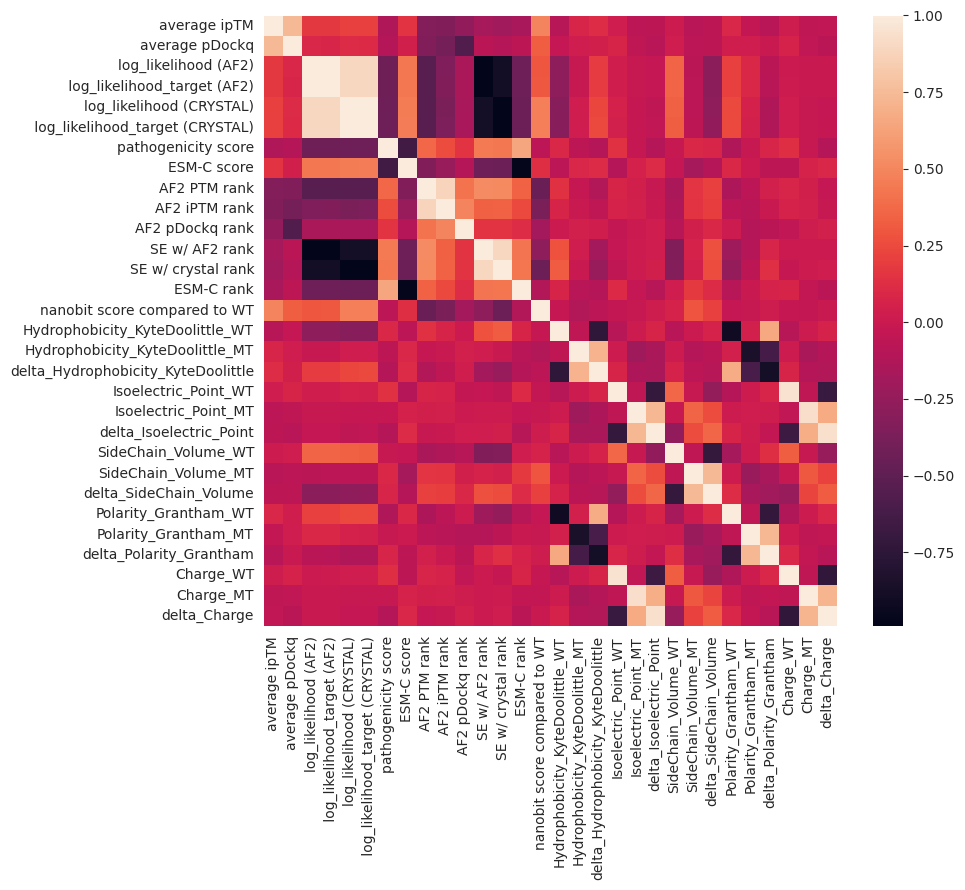

In [16]:
# Assuming merged_df is available from the previous code
feature_cols = ['average ipTM', 'average pDockq',
       'log_likelihood (AF2)', ' log_likelihood_target (AF2)',
       'log_likelihood (CRYSTAL)', ' log_likelihood_target (CRYSTAL)',
        'pathogenicity score', 'ESM-C score',
       'AF2 PTM rank', 'AF2 iPTM rank', 'AF2 pDockq rank', 'SE w/ AF2 rank',
       'SE w/ crystal rank', 'ESM-C rank', 'nanobit score compared to WT',
       'Hydrophobicity_KyteDoolittle_WT', 'Hydrophobicity_KyteDoolittle_MT',
       'delta_Hydrophobicity_KyteDoolittle', 'Isoelectric_Point_WT',
       'Isoelectric_Point_MT', 'delta_Isoelectric_Point',
       'SideChain_Volume_WT', 'SideChain_Volume_MT', 'delta_SideChain_Volume',
       'Polarity_Grantham_WT', 'Polarity_Grantham_MT',
       'delta_Polarity_Grantham', 'Charge_WT', 'Charge_MT', 'delta_Charge']
       
corr_matrix = merged_df[feature_cols].corr()
#plot heatmap
fig = plt.subplots(figsize=(10,9))#, axes = plt.subplots(rows, cols, figsize=(cols*6, rows*6), sharex=True, sharey=True)
plt.subplot()
sns.heatmap(corr_matrix, annot= False)
plt.tight_layout()
plt.savefig('CorrelationFeatureswQ.pdf') #, layout='tight') 
plt.show()

In [25]:
corr_matrix.loc['nanobit score compared to WT'].sort_values(ascending= False).head(10)

nanobit score compared to WT        1.000000
average ipTM                        0.487793
log_likelihood (CRYSTAL)            0.468848
 log_likelihood_target (CRYSTAL)    0.468733
average pDockq                      0.327244
 log_likelihood_target (AF2)        0.300676
log_likelihood (AF2)                0.297656
SideChain_Volume_MT                 0.292068
delta_SideChain_Volume              0.200191
ESM-C score                         0.124247
Name: nanobit score compared to WT, dtype: float64

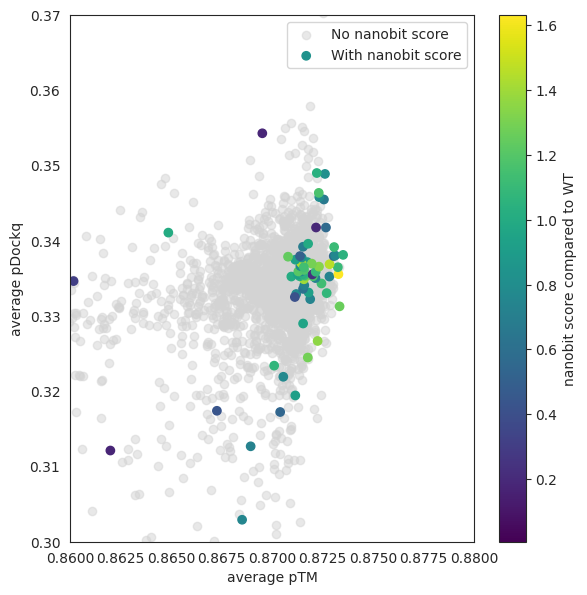

In [95]:
import matplotlib.pyplot as plt

# your columns
x = merged_df['average pTM']
y = merged_df['average pDockq']
c = merged_df['nanobit score compared to WT']

# mask on the nanobit column, not on y
has_nanobit = c.notna()

plt.figure(figsize=(6,6))

# 1) grey out points missing a nanobit score
plt.scatter(
    x[~has_nanobit],
    y[~has_nanobit],
    color='lightgray',
    label='No nanobit score',
    alpha=0.5,
    zorder=1
)

# 2) plot the rest coloured by their nanobit score
sc = plt.scatter(
    x[has_nanobit],
    y[has_nanobit],
    c=c[has_nanobit],
    cmap='viridis',
    label='With nanobit score',
    zorder=2
)

plt.colorbar(sc, label='nanobit score compared to WT')
plt.xlabel('average pTM')
plt.ylabel('average pDockq')
plt.legend()
plt.tight_layout()
plt.xlim(0.86, 0.88)
plt.ylim(0.30, 0.37)
plt.savefig('top2corr_plot_zoom.pdf')
plt.show()


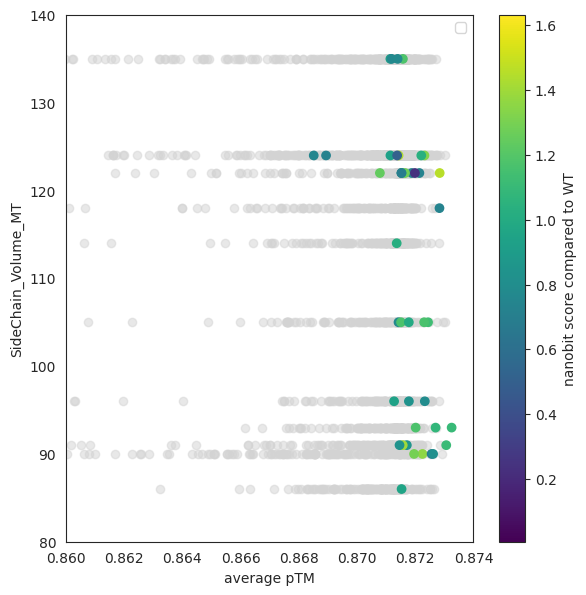

In [92]:
import matplotlib.pyplot as plt

# your columns
x = merged_df['average pTM']
y = merged_df['SideChain_Volume_MT']
c = merged_df['nanobit score compared to WT']

# mask on the nanobit column, not on y
has_nanobit = c.notna()

plt.figure(figsize=(6,6))

# 1) grey out points missing a nanobit score
plt.scatter(
    x[~has_nanobit],
    y[~has_nanobit],
    color='lightgray',
    label='No nanobit score',
    alpha=0.5,
    zorder=1
)

# 2) plot the rest coloured by their nanobit score
sc = plt.scatter(
    x[has_nanobit],
    y[has_nanobit],
    c=c[has_nanobit],
    cmap='viridis',
    label='With nanobit score',
    zorder=2
)

plt.colorbar(sc, label='nanobit score compared to WT')
plt.xlabel('average pTM')
plt.ylabel('SideChain_Volume_MT')
plt.legend([])
plt.tight_layout()
# plt.xscale('log')
# plt.yscale('log')
plt.ylim(80, 140)
plt.xlim(0.86, 0.874)
plt.show()


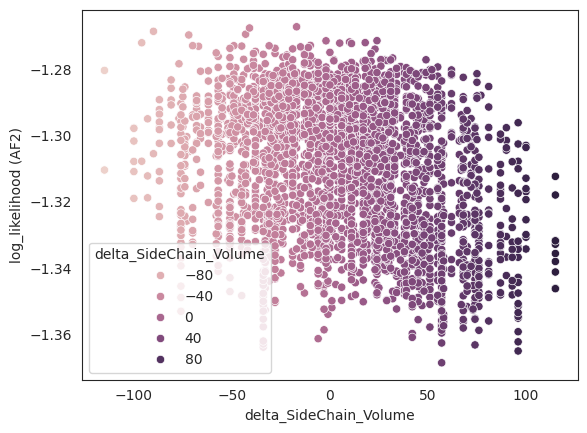

In [ ]:
sns.scatterplot(data=merged_df, y= 'log_likelihood (AF2)',
 x = 'delta_SideChain_Volume',
 hue = 'delta_SideChain_Volume')
plt.show()

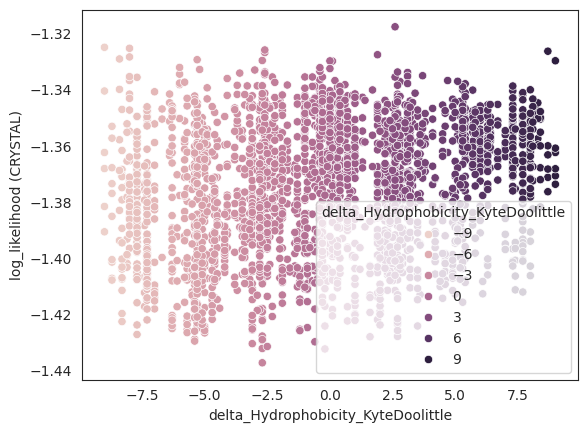

In [62]:
sns.scatterplot(data=merged_df, y= 'log_likelihood (CRYSTAL)',
 x = 'delta_Hydrophobicity_KyteDoolittle',
 hue = 'delta_Hydrophobicity_KyteDoolittle')
plt.show()

In [65]:
corr_df.sort_values(by='pearson_r')

,metric,delta_property,pearson_r
22,log_likelihood (AF2),delta_SideChain_Volume,-0.290443
27,log_likelihood_target (AF2),delta_SideChain_Volume,-0.285037
32,log_likelihood (CRYSTAL),delta_SideChain_Volume,-0.273023
37,log_likelihood_target (CRYSTAL),delta_SideChain_Volume,-0.266663
38,log_likelihood_target (CRYSTAL),delta_Polarity_Grantham,-0.130459
33,log_likelihood (CRYSTAL),delta_Polarity_Grantham,-0.126157
7,average pTM,delta_SideChain_Volume,-0.118443
41,pathogenicity score,delta_Isoelectric_Point,-0.110082
40,pathogenicity score,delta_Hydrophobicity_KyteDoolittle,-0.106611
47,ESM-C score,delta_SideChain_Volume,-0.101031
